In [153]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [154]:
train_path = "data/output/01_data_understanding/data_test.csv"
test_path = "data/output/01_data_understanding/data_train.csv"
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


### Outliers

In [155]:
from scipy.stats import kurtosis, skew

# Initialize an empty dictionary to store the results
results = {'Variable': [], 'Excess Kurtosis': [], 'Skewness': []}

for f in data_train.select_dtypes(include=['int']):
    # Append the results to the dictionary
    results['Variable'].append(f)
    results['Excess Kurtosis'].append(kurtosis(data_train[f]))
    results['Skewness'].append(skew(data_train[f]))

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Print the DataFrame
print(results_df)

        Variable  Excess Kurtosis   Skewness
0         rating         0.641692  -0.620624
1      startYear         1.097289  -1.125403
2       numVotes      1196.417746  31.558943
3    totalImages      1027.546116  28.162376
4    totalVideos       571.915330  21.354235
..           ...              ...        ...
151        Sport        62.527855   8.032923
152    Talk-Show        43.333063   6.732983
153     Thriller        15.782962   4.216985
154          War        55.545534   7.585877
155      Western        56.249160   7.632114

[156 rows x 3 columns]


In [156]:
def detect_outliers(data, columns_to_check, threshold_std_dev=2.0, threshold_iqr=1.5):
    """
    Identifies potential outliers in the specified columns of a DataFrame using two methods:
    1. Standard deviation.
    2. Interquartile range (IQR).

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_check (list): List of column names to check for outliers.
        threshold_std_dev (float): Multiplier for standard deviation threshold.
        threshold_iqr (float): Multiplier for IQR threshold.

    Returns:
        dict: A dictionary with the following keys:
            - "columns_with_outliers_std_dev": Columns with outliers detected by standard deviation.
            - "columns_with_outliers_iqr": Columns with outliers detected by IQR.
            - "common_outlier_columns": Columns with outliers detected by both methods.
    """
    # Select only the specified columns
    numeric_columns = data[columns_to_check]

    # Calculate quartiles and IQR
    quartiles = numeric_columns.quantile([0.25, 0.75])
    lower_quartile = quartiles.loc[0.25]
    upper_quartile = quartiles.loc[0.75]
    interquartile_range = upper_quartile - lower_quartile

    # Identify outliers using the standard deviation method
    outliers_std_dev = (numeric_columns - numeric_columns.mean()).abs() > threshold_std_dev * numeric_columns.std()

    # Identify outliers using the IQR method
    outliers_iqr = (numeric_columns < lower_quartile - threshold_iqr * interquartile_range) | \
                   (numeric_columns > upper_quartile + threshold_iqr * interquartile_range)

    # Determine columns with outliers for each method
    columns_with_outliers_std_dev = numeric_columns.columns[outliers_std_dev.any()]
    columns_with_outliers_iqr = numeric_columns.columns[outliers_iqr.any()]

    # Find common columns with outliers detected by both methods
    common_outlier_columns = columns_with_outliers_std_dev.intersection(columns_with_outliers_iqr)

    return {
        "columns_with_outliers_std_dev": columns_with_outliers_std_dev.tolist(),
        "columns_with_outliers_iqr": columns_with_outliers_iqr.tolist(),
        "common_outlier_columns": common_outlier_columns.tolist()
    }

# Example usage:
columns_to_check = [
    "rating",
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres"
]

outliers_info = detect_outliers(data_train, columns_to_check)
print("\nColumns with potential outliers detected by standard deviation:")
print(outliers_info["columns_with_outliers_std_dev"])
print("\nColumns with potential outliers detected by IQR:")
print(outliers_info["columns_with_outliers_iqr"])
print("\nColumns with potential outliers detected by both methods:")
print(outliers_info["common_outlier_columns"])



Columns with potential outliers detected by standard deviation:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']

Columns with potential outliers detected by IQR:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']

Columns with potential outliers detected by both methods:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']


# Correlation
Let's analyze the correlations between columns.

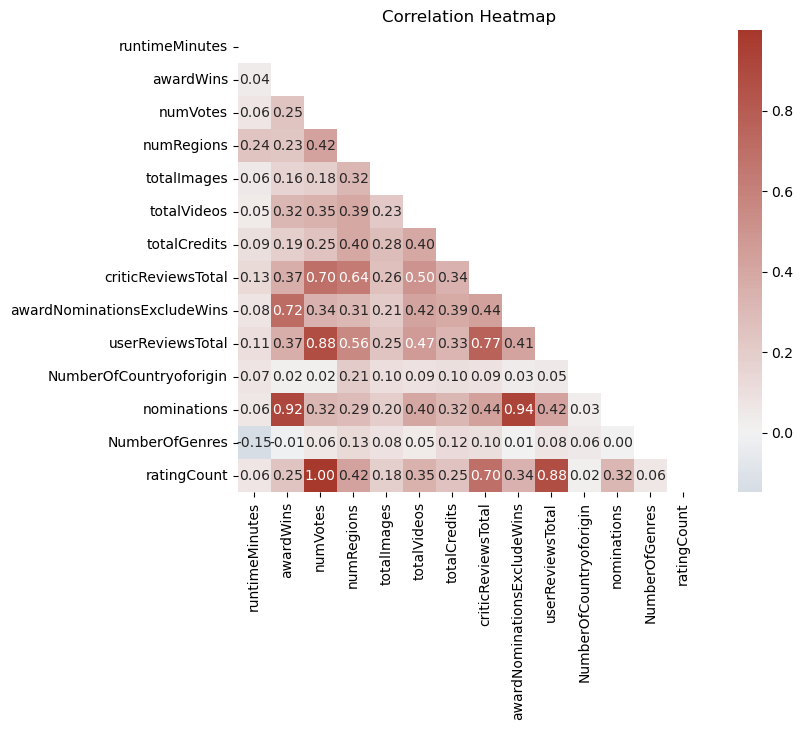


Top-10 Correlation Pairs:
                      Variable 1          Variable 2  Correlation
41                      numVotes         ratingCount     1.000000
123  awardNominationsExcludeWins         nominations     0.936053
155                  nominations           awardWins     0.915546
191                  ratingCount    userReviewsTotal     0.877161
37                      numVotes    userReviewsTotal     0.877141
107           criticReviewsTotal    userReviewsTotal     0.769349
113  awardNominationsExcludeWins           awardWins     0.715477
111           criticReviewsTotal         ratingCount     0.702623
35                      numVotes  criticReviewsTotal     0.702583
101           criticReviewsTotal          numRegions     0.638356

Bottom-10 Correlation Pairs:
                  Variable 1                   Variable 2  Correlation
70               totalVideos               runtimeMinutes     0.047462
1             runtimeMinutes                    awardWins     0.039634
148 

In [157]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def analyze_correlation(data, columns, show_plot=True, top_n=10):
    """
    Analyze the correlation matrix for a subset of columns, optionally visualize a heatmap, 
    and return the top-N and bottom-N correlation pairs.
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to include in the correlation analysis.
        show_plot (bool): Whether to display the heatmap. Default is True.
        top_n (int): Number of top and bottom correlation pairs to return. Default is 10.
    
    Returns:
        tuple: Two DataFrames containing the top-N and bottom-N correlation pairs.
    """
    # Filter the DataFrame to include only the desired subset of columns
    subset_data = data[columns]
    
    # Compute the correlation matrix for the subset
    corr_matrix = subset_data.corr()

    if show_plot:
        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create a custom diverging palette
        cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

        # Plot the heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(corr_matrix, mask=mask, center=0, annot=True, fmt='.2f', square=True, cmap=cmap)
        plt.title("Correlation Heatmap")
        plt.show()

    # Flatten the correlation matrix and reset the index to get all pairs
    corr_pairs = corr_matrix.abs().unstack().reset_index()

    # Rename the columns for better understanding
    corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

    # Remove self-correlations (correlation of a variable with itself)
    corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

    # Sort by correlation value in descending order
    sorted_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)

    # Drop duplicate pairs (e.g., A-B and B-A)
    sorted_corr_pairs = sorted_corr_pairs.drop_duplicates(subset=['Correlation'])

    # Get the top-N and bottom-N correlation pairs
    top_corr_pairs = sorted_corr_pairs.head(top_n)
    bottom_corr_pairs = sorted_corr_pairs.tail(top_n)

    return top_corr_pairs, bottom_corr_pairs

# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres",
    "ratingCount"
]

# Analyze the correlation matrix for the specified columns
top_corr_pairs, bottom_corr_pairs = analyze_correlation(data_train, subset_columns)

# Print the top-10 and bottom-10 correlation pairs
print("\nTop-10 Correlation Pairs:")
print(top_corr_pairs)

print("\nBottom-10 Correlation Pairs:")
print(bottom_corr_pairs)

In [158]:
data_train = data_train.drop(columns='ratingCount')
data_test = data_test.drop(columns='ratingCount')


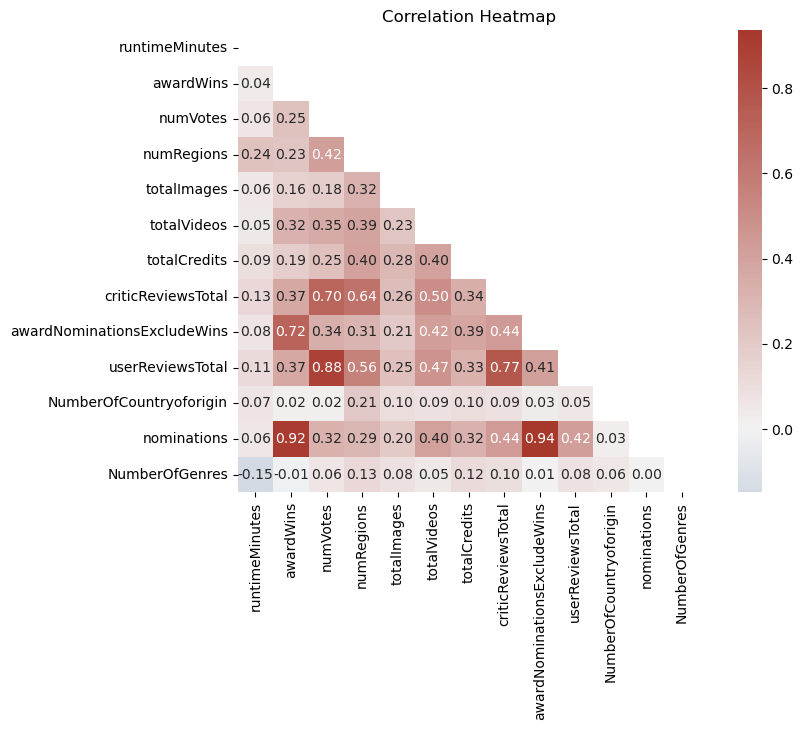


Top-10 Correlation Pairs:
                      Variable 1          Variable 2  Correlation
115  awardNominationsExcludeWins         nominations     0.936053
24                     awardWins         nominations     0.915546
35                      numVotes    userReviewsTotal     0.877141
124             userReviewsTotal  criticReviewsTotal     0.769349
105  awardNominationsExcludeWins           awardWins     0.715477
33                      numVotes  criticReviewsTotal     0.702583
46                    numRegions  criticReviewsTotal     0.638356
48                    numRegions    userReviewsTotal     0.557024
72                   totalVideos  criticReviewsTotal     0.497604
122             userReviewsTotal         totalVideos     0.469540

Bottom-10 Correlation Pairs:
                      Variable 1                   Variable 2  Correlation
77                   totalVideos               NumberOfGenres     0.048069
5                 runtimeMinutes                  totalVideos     0

In [159]:
# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres",
]

# Analyze the correlation matrix for the specified columns
top_corr_pairs, bottom_corr_pairs = analyze_correlation(data_train, subset_columns)

# Print the top-10 and bottom-10 correlation pairs
print("\nTop-10 Correlation Pairs:")
print(top_corr_pairs)

print("\nBottom-10 Correlation Pairs:")
print(bottom_corr_pairs)

# Standardize
| **Colonna**           | **Tecnica Richiesta**                      | **Trasformazione**        | **Motivo**                                                                                       |
|------------------------|--------------------------------------------|---------------------------|--------------------------------------------------------------------------------------------------|
| **`runtimeMinutes`**   | Clustering (K-means, DBSCAN)               | Radice quadrata           | Riduce l'effetto di valori estremi senza comprimere troppo i valori medi. Utile per clustering. |
| **`awardWins`**        | Classification (Decision Trees, KNN)       | Logaritmo (\(\log(x+1)\)) | Comprime i valori alti e rende la distribuzione più uniforme per KNN e altre metriche.          |
| **`numVotes`**         | Clustering e Classification                | Logaritmo (\(\log(x+1)\)) | Distribuzione molto sbilanciata, il logaritmo bilancia l'influenza dei valori estremi.          |
| **`totalImages`**      | Clustering                                 | Logaritmo (\(\log(x+1)\)) | Molti valori piccoli e una coda lunga; il log riduce la variazione mantenendo la scala.         |
| **`totalVideos`**      | Classification                             | Radice quadrata           | Valori discreti e moderatamente sbilanciati, la radice gestisce bene la distribuzione.          |
| **`totalCredits`**     | Clustering e Classification                | Logaritmo (\(\log(x+1)\)) | Valori con ampia varianza; il log bilancia le differenze.                                       |
| **`criticReviewsTotal`** | Pattern Mining                            | Logaritmo (\(\log(x+1)\)) | Necessario per analisi frequenti, riduce l'impatto dei valori alti nei pattern estratti.        |

### Dettagli delle scelte

1. **Radice quadrata**
   - **Quando**: Per colonne con valori discreti e moderatamente sbilanciati.
   - **Perché**: Mantiene una buona distinzione tra valori bassi e medi, riducendo l'effetto degli outlier.

2. **Logaritmo**
   - **Quando**: Per colonne con una distribuzione molto sbilanciata (long-tail).
   - **Perché**: Comprime i valori alti e bilancia la distribuzione, utile per algoritmi sensibili alla scala (e.g., KNN, K-means).

### Motivazioni

1. **Clustering**:
   - K-means e DBSCAN sono sensibili alla scala e alla varianza. Colonne con distribuzioni sbilanciate richiedono normalizzazioni (radice o logaritmo) per evitare che un attributo domini sugli altri.

2. **Classification**:
   - KNN e Decision Trees funzionano meglio con dati bilanciati e privi di outlier. La trasformazione logaritmica è ideale per compressioni consistenti, mentre la radice quadrata funziona meglio per valori discreti.

3. **Pattern Mining**:
   - Le colonne utilizzate nei pattern (e.g., frequenze) devono essere compresse per evitare che poche occorrenze alte dominino i risultati.

Per le altre colonne, ecco un'analisi più completa delle loro caratteristiche e delle potenziali trasformazioni:

---

### **Colonne aggiuntive**

#### **`rating`**
- **Descrizione**: Valutazioni numeriche su una scala discreta (es. 1-10).
- **Distribuzione**: Probabilmente concentrata tra 6 e 8 (basata su distribuzioni simili di rating).
- **Trasformazione suggerita**: **Nessuna**.
  - **Motivo**: La scala è già normalizzata e discreta, e i valori non necessitano di compressione o ridimensionamento.

---

#### **`startYear`**
- **Descrizione**: Anno di rilascio.
- **Distribuzione**: Valori distribuiti su un intervallo lungo, ma lineare.
- **Trasformazione suggerita**: **Nessuna**.
  - **Motivo**: Il valore è significativo come anno cronologico. Se necessario, può essere discretizzato (es. decade).

---

#### **`awardNominationsExcludeWins`**
- **Descrizione**: Numero di nomination escludendo le vittorie.
- **Distribuzione**: Ampia varianza con molti zeri e valori bassi.
- **Trasformazione suggerita**: **Logaritmo (\(\log(x+1)\))**.
  - **Motivo**: Per gestire la coda lunga e ridurre l’impatto dei valori molto grandi.

---

#### **`startYearDecade`**
- **Descrizione**: Decade derivata dall’anno di rilascio.
- **Distribuzione**: Valori discreti e categoriali (es. 1980, 1990).
- **Trasformazione suggerita**: **Nessuna**.
  - **Motivo**: È già una variabile categoriale.

---

#### **Generi (e.g., `Action`, `Romance`, `Sci-Fi`)**
- **Descrizione**: Variabili binarie che indicano la presenza di un genere (0 o 1).
- **Trasformazione suggerita**: **Nessuna**.
  - **Motivo**: Le variabili binarie sono già normalizzate per natura e non richiedono trasformazioni.

---

### **Criteri per la scelta**
1. **Nessuna trasformazione**: Se la colonna è già normalizzata o non è numerica (e.g., `startYear`, `rating`).
2. **Logaritmo (\(\log(x+1)\))**: Per variabili con alta varianza, molti zeri, e valori estremamente alti.
3. **Radice quadrata (\(\sqrt{x}\))**: Per variabili numeriche con distribuzione discreta e range moderato.

In [160]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def transform_data(df):
    """
    Trasforma le colonne di un DataFrame secondo le regole definite.

    Args:
        df (pd.DataFrame): Il dataset originale.

    Returns:
        pd.DataFrame: Il dataset trasformato.
    """
    # Copia il DataFrame per evitare modifiche non volute
    transformed_df = df.copy()

    # Definizione delle trasformazioni
    transformations = {
        'runtimeMinutes': 'sqrt',  # Radice quadrata
        'awardWins': 'log',       # Logaritmo
        'numVotes': 'log',        # Logaritmo
        'totalImages': 'log',     # Logaritmo
        'totalVideos': 'sqrt',    # Radice quadrata
        'totalCredits': 'log',    # Logaritmo
        'criticReviewsTotal': 'log',  # Logaritmo
        'awardNominationsExcludeWins': 'log',  # Logaritmo
        'userReviewsTotal': 'log',  # Logaritmo
        'nominations': 'log'  # Logaritmo
    }

    for column, transformation in transformations.items():
        if column in transformed_df.columns:
            # Gestione delle trasformazioni
            if transformation == 'log':
                transformed_df[column] = np.log1p(transformed_df[column].fillna(0))  # log(x+1)
            elif transformation == 'sqrt':
                transformed_df[column] = np.sqrt(transformed_df[column].fillna(0))
    return transformed_df

# Applica le trasformazioni al dataset di addestramento
scaled_train = transform_data(data_train)
# Applica le trasformazioni al dataset di test
scaled_test = transform_data(data_test)


In [161]:
def summarize_columns(dataframe, columns):
    """
    Prints the minimum, maximum, median, and average of the specified columns in the DataFrame.

    Parameters:
    dataframe (pd.DataFrame): The DataFrame containing the data.
    columns (list): List of column names to summarize.

    Returns:
    None
    """
    summary = []
    for column in columns:
        if column in dataframe.columns:
            col_data = dataframe[column]
            if pd.api.types.is_numeric_dtype(col_data):
                summary.append({
                    "Column": column,
                    "Min": col_data.min(),
                    "Max": col_data.max(),
                    "Median": col_data.median(),
                    "avg": col_data.mean(),
                    "Std Dev": col_data.std()
                })
            else:
                print(f"Skipping non-numeric column: {column}")
        else:
            print(f"Column '{column}' not found in the DataFrame.")
    print(pd.DataFrame(summary))

In [162]:
columns_to_scale = [
    "runtimeMinutes", "criticReviewsTotal",
    "numRegions", "totalVideos", "NumberOfCountryoforigin", "NumberOfGenres",
    "awardWins", "numVotes", "totalImages", "totalCredits",
    "awardNominationsExcludeWins", "userReviewsTotal", "nominations"
]
summarize_columns(data_train, columns_to_scale)

                         Column  Min        Max  Median          avg  \
0                runtimeMinutes  1.0     1050.0    60.0    62.548062   
1            criticReviewsTotal  0.0      567.0     0.0     3.216293   
2                    numRegions  1.0       63.0     1.0     3.665970   
3                   totalVideos  0.0       83.0     0.0     0.268895   
4       NumberOfCountryoforigin  1.0       13.0     1.0     1.096468   
5                NumberOfGenres  1.0        3.0     2.0     1.945310   
6                     awardWins  0.0      254.0     0.0     0.434675   
7                      numVotes  5.0  1071372.0    39.0  1578.248576   
8                   totalImages  0.0     2526.0     2.0    10.942651   
9                  totalCredits  0.0     2482.0    36.0    61.407710   
10  awardNominationsExcludeWins  0.0      256.0     0.0     0.556400   
11             userReviewsTotal  0.0     2423.0     0.0     7.709077   
12                  nominations  0.0      409.0     0.0     0.99

In [163]:
summarize_columns(data_test, columns_to_scale)

                         Column  Min       Max  Median          avg  \
0                runtimeMinutes  0.0    3000.0    57.0    60.710524   
1            criticReviewsTotal  0.0     533.0     0.0     2.880142   
2                    numRegions  1.0      69.0     1.0     3.619415   
3                   totalVideos  0.0     258.0     0.0     0.264144   
4       NumberOfCountryoforigin  1.0      10.0     1.0     1.095368   
5                NumberOfGenres  1.0       3.0     2.0     1.944311   
6                     awardWins  0.0     145.0     0.0     0.424567   
7                      numVotes  5.0  966565.0    38.0  1544.254145   
8                   totalImages  0.0    3504.0     2.0    11.748450   
9                  totalCredits  0.0   15742.0    35.0    62.573535   
10  awardNominationsExcludeWins  0.0     197.0     0.0     0.570054   
11             userReviewsTotal  0.0    5727.0     0.0     7.475066   
12                  nominations  0.0     306.0     0.0     0.994621   

     

In [164]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

test = store_dataset(data_test, 'data/output/02_data_understanding/data_train')
train = store_dataset(data_train, 'data/output/02_data_understanding/data_test')

test_scaled = store_dataset(scaled_test, 'data/output/02_data_understanding/scaled_data_train')
train_scaled = store_dataset(scaled_train, 'data/output/02_data_understanding/scaled_data_test')

Dataset successfully stored as data/output/02_data_understanding/data_train.csv
Dataset successfully stored as data/output/02_data_understanding/data_test.csv
Dataset successfully stored as data/output/02_data_understanding/scaled_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/scaled_data_test.csv


# Outlier detection

In [165]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_and_store_outliers_union(data1, data2, column, group_by, iqr_multipliers, output_path, show_plot=False, detect_lower_outliers=True):
    """
    Calculate and visualize outliers for a numeric column grouped by another column
    using the union of two datasets. Save a summary table with the number of outliers 
    for each group and IQR multiplier as a column to a CSV file, including the percentage 
    of theoretical elimination for each dataset.

    Args:
        data1 (pd.DataFrame): The first input dataset.
        data2 (pd.DataFrame): The second input dataset.
        column (str): The numeric column to analyze for outliers.
        group_by (str): The column to group by.
        iqr_multipliers (list of float): A list of multipliers for the IQR to define outlier boundaries.
        output_path (str): The path to save the summary CSV file.
        show_plot (bool, optional): Whether to calculate and display plots. Default is False.
        detect_lower_outliers (bool, optional): Whether to detect lower outliers. Default is True.
    """
    # Combine the datasets
    combined_data = pd.concat([data1, data2], ignore_index=True)

    if column not in combined_data.columns:
        raise ValueError(f"Column '{column}' not found in the datasets.")

    if group_by not in combined_data.columns:
        raise ValueError(f"Group-by column '{group_by}' not found in the datasets.")

    grouped = combined_data.groupby(group_by)
    summary = []

    # Calculate and store outliers for each group and IQR multiplier
    for group_name, group_data in grouped:
        group_summary = {"Group": group_name}

        for iqr_multiplier in iqr_multipliers:
            # Exclude null values for outlier calculations
            group_data_non_null = group_data[group_data[column].notnull() & (group_data[column] != 0)]

            # Calculate statistics
            q1 = group_data_non_null[column].quantile(0.25)
            q3 = group_data_non_null[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - iqr_multiplier * iqr if detect_lower_outliers else float('-inf')
            upper_bound = q3 + iqr_multiplier * iqr

            # Identify outliers
            outliers = group_data_non_null[(group_data_non_null[column] < lower_bound) | (group_data_non_null[column] > upper_bound)]
            num_outliers = len(outliers)

            # Calculate total elements for group, excluding zeros
            total_elements = len(group_data[group_data[column] != 0])

            # Save percentage of outliers for the group
            percentage_outliers = (num_outliers / total_elements * 100) if total_elements > 0 else 0

            group_summary[f"IQR_{iqr_multiplier}"] = num_outliers
            group_summary[f"Percentage_IQR_{iqr_multiplier}"] = percentage_outliers

        summary.append(group_summary)

    # Convert the summary into a DataFrame and save it to a CSV file
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(output_path, index=False)

    if show_plot:
        # Restructure data for plotting percentages by group
        plot_data = []

        for iqr_multiplier in iqr_multipliers:
            for group_summary in summary:
                group = group_summary["Group"]
                percentage = group_summary[f"Percentage_IQR_{iqr_multiplier}"]
                plot_data.append({"IQR": iqr_multiplier, "Group": group, "Percentage": percentage})

        plot_df = pd.DataFrame(plot_data)

        # Create plot
        plt.figure(figsize=(12, 8))
        for group in plot_df["Group"].unique():
            subset = plot_df[plot_df["Group"] == group]
            plt.plot(
                subset["IQR"], 
                subset["Percentage"], 
                marker="o", 
                label=f"Group: {group}"
            )

        plt.title("Percentage of Outliers by Group vs IQR Multipliers")
        plt.xlabel("IQR Multiplier")
        plt.ylabel("Percentage of Outliers")
        plt.legend()
        plt.grid(True)
        plt.show()


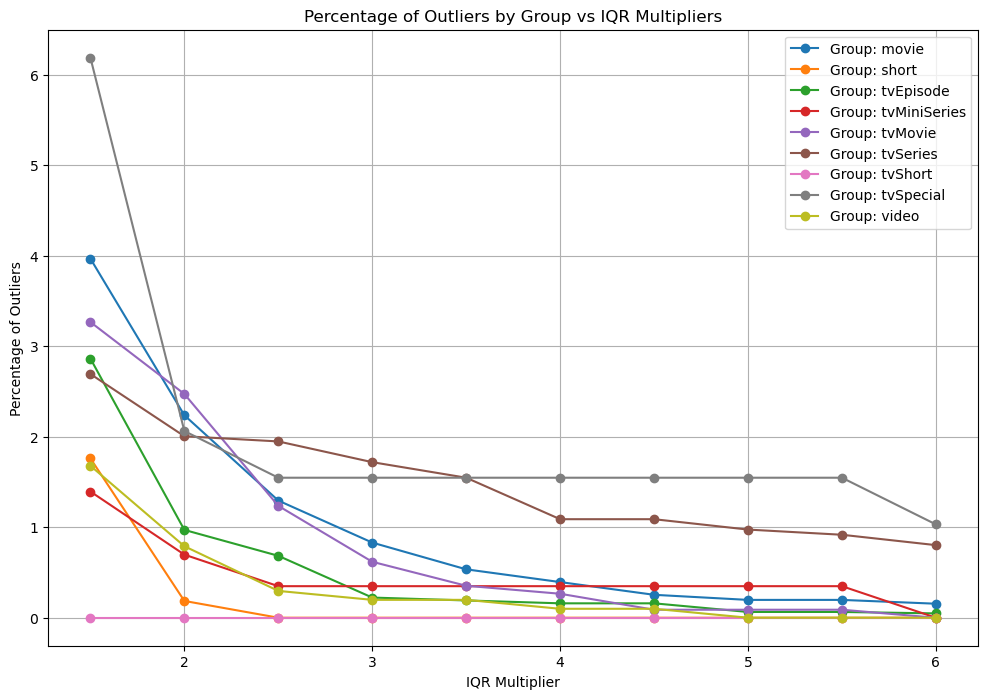

In [166]:
iqrs = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]

output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_runtimeMinutes.csv"
calculate_and_store_outliers_union(data_train, data_test, "runtimeMinutes", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)



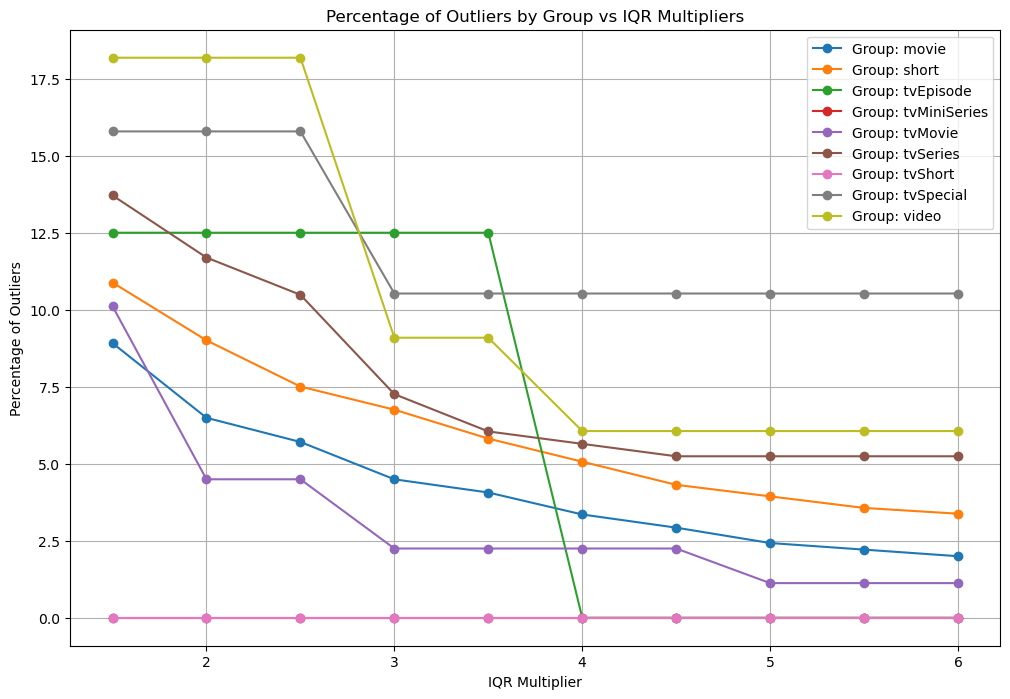

In [167]:

output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_awardWins.csv"
calculate_and_store_outliers_union(data_train, data_test, "awardWins", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)


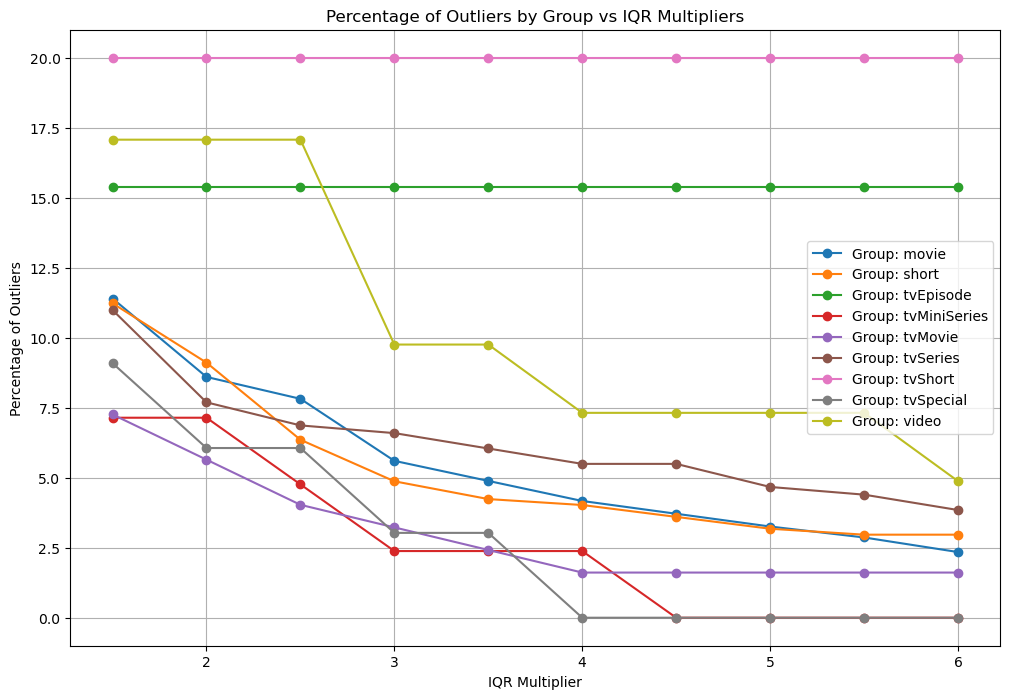

In [168]:

output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_awardNominationsExcludeWins.csv"
calculate_and_store_outliers_union(data_train, data_test, "awardNominationsExcludeWins", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)


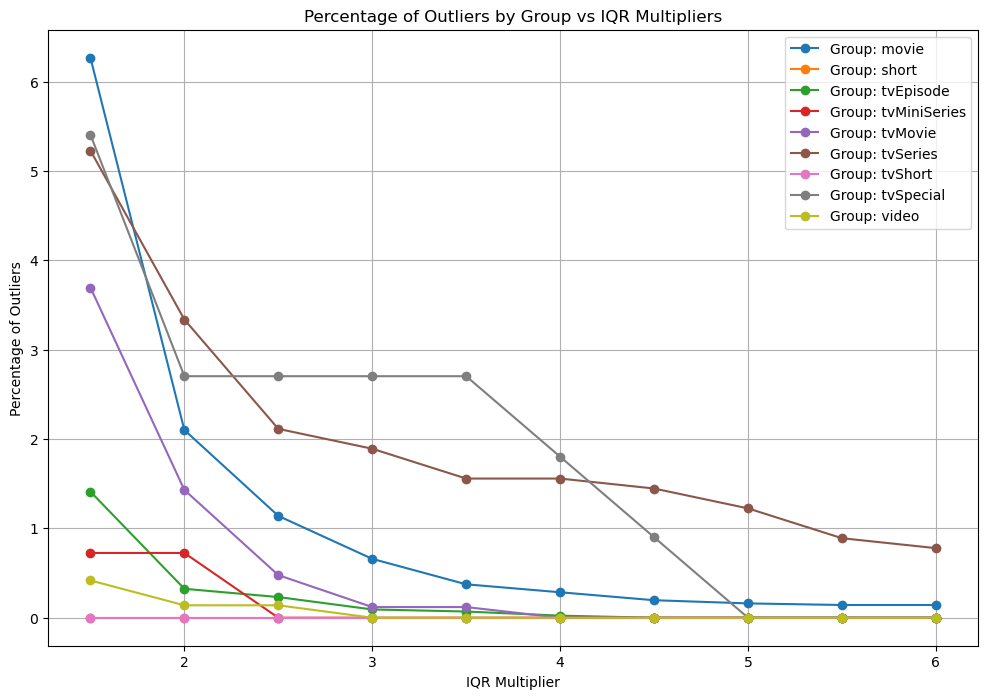

In [169]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_scaled_union_runtimeMinutes.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "runtimeMinutes", "titleType", iqrs, output_file, show_plot=True)

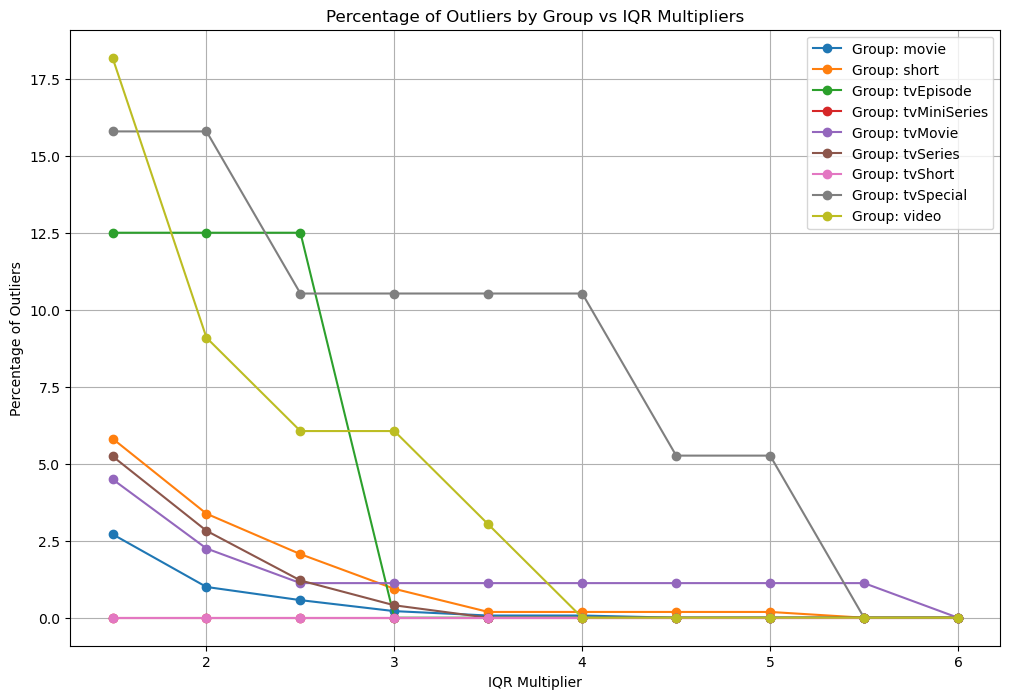

In [170]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_scaled_union_awardWins.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "awardWins", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)


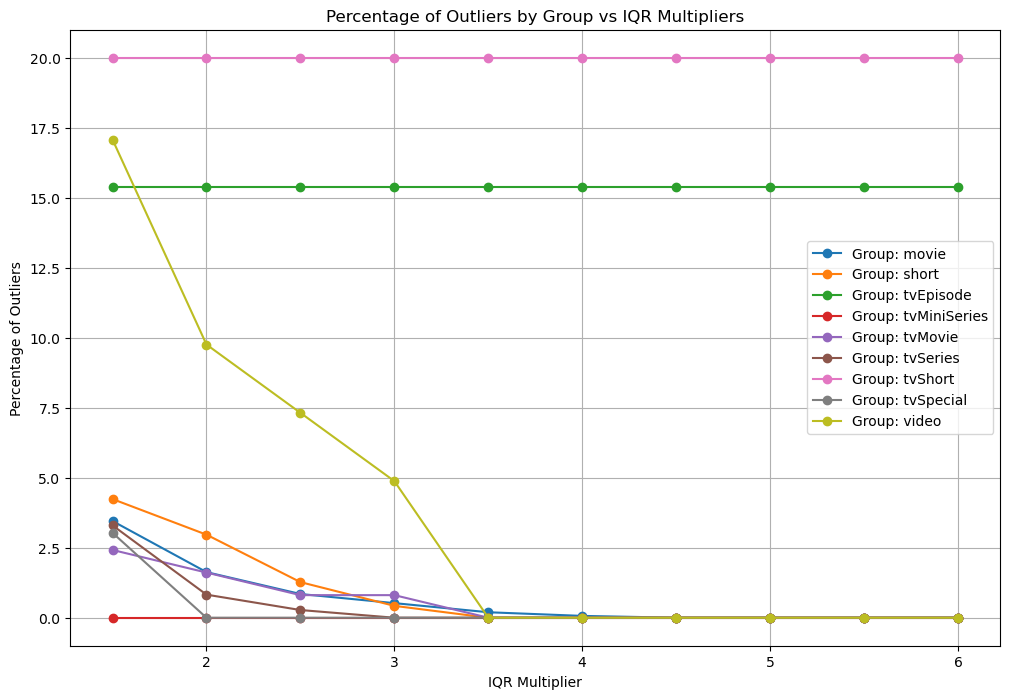

In [171]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_scaled_union_awardNominationsExcludeWins.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "awardNominationsExcludeWins", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)


In [172]:
import pandas as pd

def remove_outliers_based_on_iqr(
    train_set,
    test_set,
    normalized_train_set,
    normalized_test_set,
    columns,
    iqr_multiplier,
    group_by=None,
    detect_upper_outliers=True
):
    """
    Rimuove gli outlier individuati nei dataset normalizzati secondo l'IQR specificato per più colonne.

    Args:
        train_set (pd.DataFrame): Dataset di addestramento originale.
        test_set (pd.DataFrame): Dataset di test originale.
        normalized_train_set (pd.DataFrame): Dataset di addestramento normalizzato.
        normalized_test_set (pd.DataFrame): Dataset di test normalizzato.
        columns (list of str): Le colonne su cui calcolare gli outlier.
        iqr_multiplier (float): Il moltiplicatore IQR per definire i confini degli outlier.
        group_by (str, optional): Colonna opzionale per raggruppare i dati prima di calcolare l'IQR.
        detect_upper_outliers (bool, optional): Se True, rileva solo gli outlier superiori. Default True.

    Returns:
        tuple: Tuple contenente i dataset originali e normalizzati senza outlier (train_set, test_set, normalized_train_set, normalized_test_set).
    """
    # Aggiungi una colonna di riferimento per distinguere train e test
    normalized_train_set['source'] = 'train'
    normalized_test_set['source'] = 'test'

    # Combinare i dataset normalizzati per calcolo unico degli outlier
    combined_normalized = pd.concat([normalized_train_set, normalized_test_set], ignore_index=True)

    # Controlla che le colonne esistano
    for column in columns:
        if column not in combined_normalized.columns:
            raise ValueError(f"Column '{column}' not found in the normalized datasets.")

    combined_mask = pd.Series(True, index=combined_normalized.index)

    # Calcolare i confini IQR per ogni colonna
    for column in columns:
        if group_by:
            grouped = combined_normalized.groupby(group_by)
            masks = []

            for group_name, group_data in grouped:
                group_data_non_zero = group_data[group_data[column].notnull() & (group_data[column] != 0)]
                q1 = group_data_non_zero[column].quantile(0.25)
                q3 = group_data_non_zero[column].quantile(0.75)
                iqr = q3 - q1
                lower_bound = q1 if not detect_upper_outliers else float('-inf')
                upper_bound = q3 + iqr_multiplier * iqr

                mask = (group_data[column] >= lower_bound) & (group_data[column] <= upper_bound)
                masks.append(mask)

            group_mask = pd.concat(masks, ignore_index=True)
            combined_mask &= group_mask
        else:
            combined_normalized_non_zero = combined_normalized[combined_normalized[column] != 0]
            q1 = combined_normalized_non_zero[column].quantile(0.25)
            q3 = combined_normalized_non_zero[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 if not detect_upper_outliers else float('-inf')
            upper_bound = q3 + iqr_multiplier * iqr

            column_mask = (combined_normalized[column] >= lower_bound) & (combined_normalized[column] <= upper_bound)
            combined_mask &= column_mask

    # Applicare la maschera per individuare gli indici da mantenere
    valid_indices = combined_mask[combined_mask].index

    # Filtra gli outlier basandosi sulla maschera invertita
    outlier_indices = combined_mask[~combined_mask].index

    # Suddividere nuovamente i dataset in train e test basandosi sulla colonna 'source'
    cleaned_combined = combined_normalized.loc[valid_indices]
    outliers_combined = combined_normalized.loc[outlier_indices]

    # Filtra i dataset normalizzati senza utilizzare il metodo iloc diretto
    cleaned_train_set = train_set.iloc[cleaned_combined[cleaned_combined['source'] == 'train'].index]
    cleaned_test_set = test_set.iloc[cleaned_combined[cleaned_combined['source'] == 'test'].index - len(normalized_train_set)]

    cleaned_normalized_train_set = normalized_train_set.iloc[cleaned_combined[cleaned_combined['source'] == 'train'].index]
    cleaned_normalized_test_set = normalized_test_set.iloc[cleaned_combined[cleaned_combined['source'] == 'test'].index - len(normalized_train_set)]

    # Outliers
    outliers_train_set = train_set.iloc[outliers_combined[outliers_combined['source'] == 'train'].index]
    outliers_test_set = test_set.iloc[outliers_combined[outliers_combined['source'] == 'test'].index - len(normalized_train_set)]

    outliers_train_set.to_csv("data/output/02_data_understanding/outliers_detected/train_set.csv", index=False)
    outliers_test_set.to_csv("data/output/02_data_understanding/outliers_detected/test_set.csv", index=False)

    return cleaned_train_set, cleaned_test_set, cleaned_normalized_train_set, cleaned_normalized_test_set


In [173]:
columns_to_check_outliers = [
    "runtimeMinutes", 
    "awardWins", 
    "awardNominationsExcludeWins"]

clean_train_set, clean_test_set, clean_normalized_train_set, clean_normalized_test_set = remove_outliers_based_on_iqr(data_train, data_test, scaled_train, scaled_test, columns_to_check_outliers, 3, group_by = "titleType", detect_upper_outliers=True)

# Fill missing values with median

In [174]:
def fill_missing_values_with_median(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specified column with the median value of the column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing the column to fill and the group-by column.
        column_to_fill (str): The column in which to fill missing values.
        group_by_column (str): The column to group by when calculating the median.

    Returns:
        pd.DataFrame: A DataFrame with missing values in the specified column filled.
    """
    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Work on a copy of the data to avoid unintended side-effects
    data = data.copy()

    # Replace '\N' with NaN for proper handling of missing values
    data.loc[:, column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')  # Ensure numeric type
    data.loc[:, group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string

    # Fill missing values with the median of the group
    data.loc[:, column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    return data


In [175]:
clean_train_set = fill_missing_values_with_median(clean_train_set, "runtimeMinutes", "titleType")
clean_test_set = fill_missing_values_with_median(clean_test_set, "runtimeMinutes", "titleType")
clean_normalized_train_set = fill_missing_values_with_median(clean_normalized_train_set, "runtimeMinutes", "titleType")
clean_normalized_test_set = fill_missing_values_with_median(clean_normalized_test_set, "runtimeMinutes", "titleType")

# Correlation

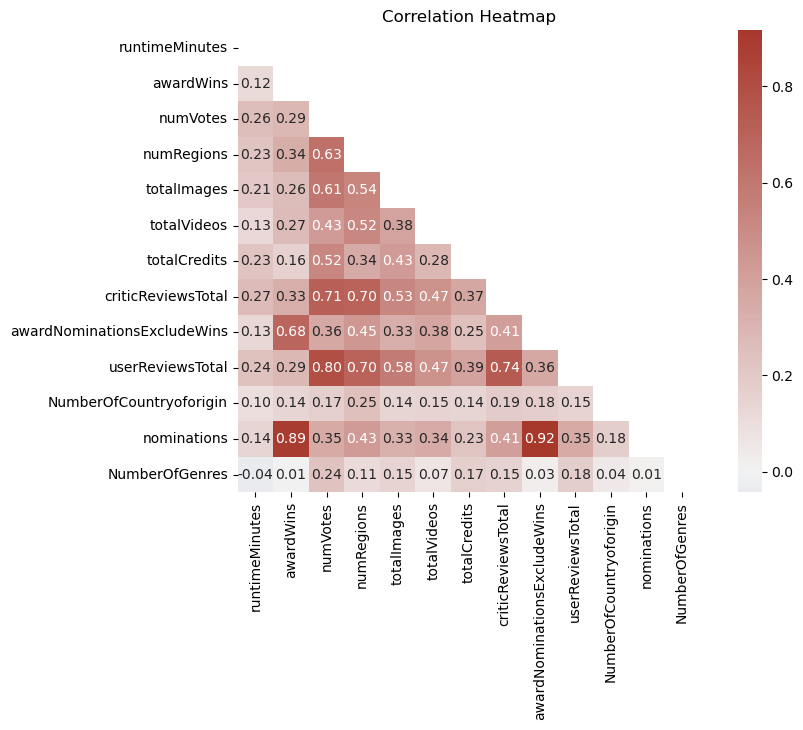

(                      Variable 1          Variable 2  Correlation
 115  awardNominationsExcludeWins         nominations     0.916536
 24                     awardWins         nominations     0.889520
 35                      numVotes    userReviewsTotal     0.795822
 124             userReviewsTotal  criticReviewsTotal     0.736896
 33                      numVotes  criticReviewsTotal     0.707568
 46                    numRegions  criticReviewsTotal     0.698580
 120             userReviewsTotal          numRegions     0.696313
 105  awardNominationsExcludeWins           awardWins     0.684140
 29                      numVotes          numRegions     0.628611
 54                   totalImages            numVotes     0.607047,
          Variable 1                   Variable 2  Correlation
 65      totalVideos               runtimeMinutes     0.128459
 1    runtimeMinutes                    awardWins     0.115328
 159  NumberOfGenres                   numRegions     0.112586
 10   runt

In [176]:
# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres",
]
analyze_correlation(clean_normalized_test_set, subset_columns, show_plot=True)

# One-hot encoding `titleType`

In [177]:
def one_hot_encoding(data, column_name, columns_file, replace_null_with_unknown=False):
    """
    Performs one-hot encoding on a specified column of a DataFrame.

    Args:
        data (pd.DataFrame): Input DataFrame.
        column_name (str): Column to be one-hot encoded.def plot_missing_values_by_title_type_combined(
        data_train = data_train, 
        data_test= data_test, 
        global_title= "missing values",
        train_title =  "train", 
        test_title = "test")
def plot_missing_values_by_title_type_combined(data_train, data_test, global_title, train_title, test_title):
    
        columns_file (str): File to save the new column names.
        replace_null_with_unknown (bool): Replace '\\N' with 'unknown<ColumnName>' if True.

    Returns:
        pd.DataFrame: Updated DataFrame with one-hot encoded columns.
    """
    # Ensure the specified column is a string and clean it
    data[column_name] = data[column_name].astype(str)

    # Replace '\N' with 'unknown<ColumnName>' if specified
    if replace_null_with_unknown:
        unknown_value = f"unknown{column_name.capitalize()}"
        data[column_name] = data[column_name].replace(r"\\N", unknown_value, regex=True)

    # Split the string into a list, cleaning brackets, quotes, and leading/trailing spaces
    data[column_name] = data[column_name].apply(lambda x: [item.strip() for item in x.strip("[]").replace("'", "").split(",")])

    # One-hot encode the specified column
    column_one_hot = pd.get_dummies(data[column_name].apply(pd.Series).stack()).groupby(level=0).sum()

    # Concatenate the one-hot encoded columns with the original dataset
    data = pd.concat([data, column_one_hot], axis=1)

    # Save the names of new columns to a file
    new_columns = list(column_one_hot.columns)
    with open(columns_file, 'w') as f:
        for column in new_columns:
            f.write(f"{column}\n")

    # Remove the original column
    data.drop(columns=[column_name], inplace=True)

    return data




def merge_txt_files(output_file, *input_files):
    merged_lines = set()
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.read().splitlines()
            for line in lines:
                merged_lines.add(line.strip())
    
    with open(output_file, 'w') as f:
        for line in sorted(merged_lines):
            f.write(f"{line}\n")

In [178]:
one_hot_encoding(clean_normalized_train_set, "titleType", 'encoding_lists/titleType_normalized_train.txt')
one_hot_encoding(clean_normalized_test_set, "titleType", 'encoding_lists/titleType_normalized_test.txt')

merge_txt_files('encoding_lists/titleType_normalized.txt', 'encoding_lists/titleType_normalized_train.txt', 'encoding_lists/titleType_normalized_test.txt')

one_hot_encoding(clean_train_set, "titleType", 'encoding_lists/titleType_train.txt')
one_hot_encoding(clean_test_set, "titleType", 'encoding_lists/titleType_test.txt')

merge_txt_files('encoding_lists/titleType.txt', 'encoding_lists/titleType_train.txt', 'encoding_lists/titleType_test.txt')

merge_txt_files('encoding_lists/titleType.txt', 'encoding_lists/titleType.txt', 'encoding_lists/titleType_normalized.txt')

In [179]:
# store the 4 datasets
store_dataset(scaled_train, 'data/output/02_data_understanding/scaled_data_train')
store_dataset(scaled_test, 'data/output/02_data_understanding/scaled_data_test')
store_dataset(data_train, 'data/output/02_data_understanding/data_train')
store_dataset(data_test, 'data/output/02_data_understanding/data_test')

Dataset successfully stored as data/output/02_data_understanding/scaled_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/scaled_data_test.csv
Dataset successfully stored as data/output/02_data_understanding/data_train.csv
Dataset successfully stored as data/output/02_data_understanding/data_test.csv


'data/output/02_data_understanding/data_test.csv'